# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 09: Árvores de Decisão e k-Means**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_09_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
seed = 42
np.random.seed(seed)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [3]:
url = "https://gist.githubusercontent.com/marcelovca90/de69333ef1e36f6ce4671e387f820f34/raw/29d61f2789c51a84144192a8127c5b041fa8bca2/wifi_localization.txt"

column_names = [ "AP1", "AP2", "AP3", "AP4", "AP5", "AP6", "AP7", "Room" ]

df = pd.read_csv(url, sep="\t", header=None, names=column_names)

X = df.drop(columns=["Room"]).values
y = df["Room"].values

feature_names = df.columns[:-1].tolist()

df.head()

,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room
0,-64,-56,-61,-66,-71,-82,-81,1
1,-68,-57,-61,-65,-71,-85,-85,1
2,-63,-60,-60,-67,-76,-85,-84,1
3,-61,-60,-68,-62,-77,-90,-80,1
4,-63,-65,-60,-63,-77,-81,-87,1


### <font color='#2D9CDB'>Q1) O Wireless Indoor Localization [[1]](https://archive.ics.uci.edu/dataset/422/wireless+indoor+localization)[[2]](https://archive-beta.ics.uci.edu/dataset/422/wireless+indoor+localization) é um conjunto de dados amplamente utilizado em pesquisas sobre posicionamento indoor e redes sem fio. Pesquise brevemente sobre esse dataset e descreva, em um único parágrafo, qual é o problema que ele busca resolver, quais informações são registradas em cada amostra, o significado dos valores RSSI (Received Signal Strength Indicator) e por que essa base de dados pode ser utilizada tanto em problemas de classificação quanto de clusterização.</font>

O dataset busca resolver/entender o problema/situação da localização interna(indoor). Cada amostra mapeia um vetor contendo 7 intensidades de sinal wifi capturadas por um smartphone e uma variável alvo indicando em qual dos 4 cômodos de um escritório a medição ocorreu. Esses sinais são medidos em RSSI (Received Signal Strenght Indicator), que representam a potência do sinal recebido expressa em decibéis-miliwatts. Esta base de dados pode ser empregada em tarefas de classificação, onde o modelo aprende a mapear os 7 sinais para prever o rótulo correto de uma das quatro salas, e também em tarefas de clusterização, permitindo descobrir e delimitar os cômodos de forma autônoma sem a necessidade prévia de identificação.

### <font color='#2D9CDB'>Q2) Utilizando o dataset Wireless Indoor Localization já carregado, informe a quantidade total de amostras, o número de atributos, o número de classes e os identificadores das salas presentes na base de dados. Em seguida, apresente uma tabela contendo as cinco primeiras amostras do conjunto de dados. Com base nos resultados obtidos, descreva brevemente a estrutura do dataset e o significado dos atributos e da variável alvo.</font>

In [4]:
print(f'Quantidade total de amostras: {len(df)}')
print(f'Número de atributos: {len(df.columns)}')
print(f'Número de classes: {len(df['Room'].unique())}')
print(f'Identificador das salas: {df["Room"].unique()}')
df.head(5)

Quantidade total de amostras: 2000
Número de atributos: 8
Número de classes: 4
Identificador das salas: [1 2 3 4]


,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room
0,-64,-56,-61,-66,-71,-82,-81,1
1,-68,-57,-61,-65,-71,-85,-85,1
2,-63,-60,-60,-67,-76,-85,-84,1
3,-61,-60,-68,-62,-77,-90,-80,1
4,-63,-65,-60,-63,-77,-81,-87,1


O dataset é estruturado com 8 atributos, contemplado com 1 variável alvo representativo da sala de cada amostra. Cada amostra apresenta valores para todos os atributos, não apenas o sinal de uma marcação por vez. Os atributos AP representam a potência do sinal de wifi e a variável alvo qual sala a medição foi realizada.

### <font color='#2D9CDB'>Q3) Utilizando apenas os atributos RSSI do dataset, apresente as estatísticas descritivas (contagem, média, desvio padrão, valor mínimo, quartis e valor máximo) de cada ponto de acesso Wi-Fi. Em seguida, identifique quais pontos de acesso apresentam, em média, os sinais mais fortes e os mais fracos. Com base nos resultados obtidos, comente brevemente sobre a variabilidade das medições de RSSI observadas no conjunto de dados.</font>

In [5]:
display(df.describe())

print()

print(f'Sinais mais fortes, em media: {df.drop(columns=['Room']).mean().idxmax()}')
print(f'Sinais mais fracos, em media: {df.drop(columns=['Room']).mean().idxmin()}')

,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,-52.330500,-55.623500,-54.964000,-53.566500,-62.640500,-80.985000,-81.726500,2.500000
std,11.321677,3.417688,5.316186,11.471982,9.105093,6.516672,6.519812,1.118314
min,-74.000000,-74.000000,-73.000000,-77.000000,-89.000000,-97.000000,-98.000000,1.000000
25%,-61.000000,-58.000000,-58.000000,-63.000000,-69.000000,-86.000000,-87.000000,1.750000
50%,-55.000000,-56.000000,-55.000000,-56.000000,-64.000000,-82.000000,-83.000000,2.500000
75%,-46.000000,-53.000000,-51.000000,-46.000000,-56.000000,-77.000000,-78.000000,3.250000
max,-10.000000,-45.000000,-40.000000,-11.000000,-36.000000,-61.000000,-63.000000,4.000000



Sinais mais fortes, em media: AP1
Sinais mais fracos, em media: AP7


A variabilidade dos resultados pode ser evidenciada pela média dos valores de cada medição para cada ponto de acesso. Nota-se que para medições iniciais (1 até 4), o sinal apresentou maior estabilidade, começando a piorar a partir deste ponto. AP7 é o pior caso, onde o valor chegou a -81.72, o menor relativo entre todos.

### <font color='#2D9CDB'>Q4) Construa histogramas para os sete atributos RSSI do dataset e analise a distribuição dos valores observados. Em seguida, identifique quais pontos de acesso apresentam distribuições mais concentradas e quais apresentam maior dispersão. Com base nos gráficos obtidos, discuta brevemente como essas diferenças podem influenciar tarefas de classificação e clusterização.</font>

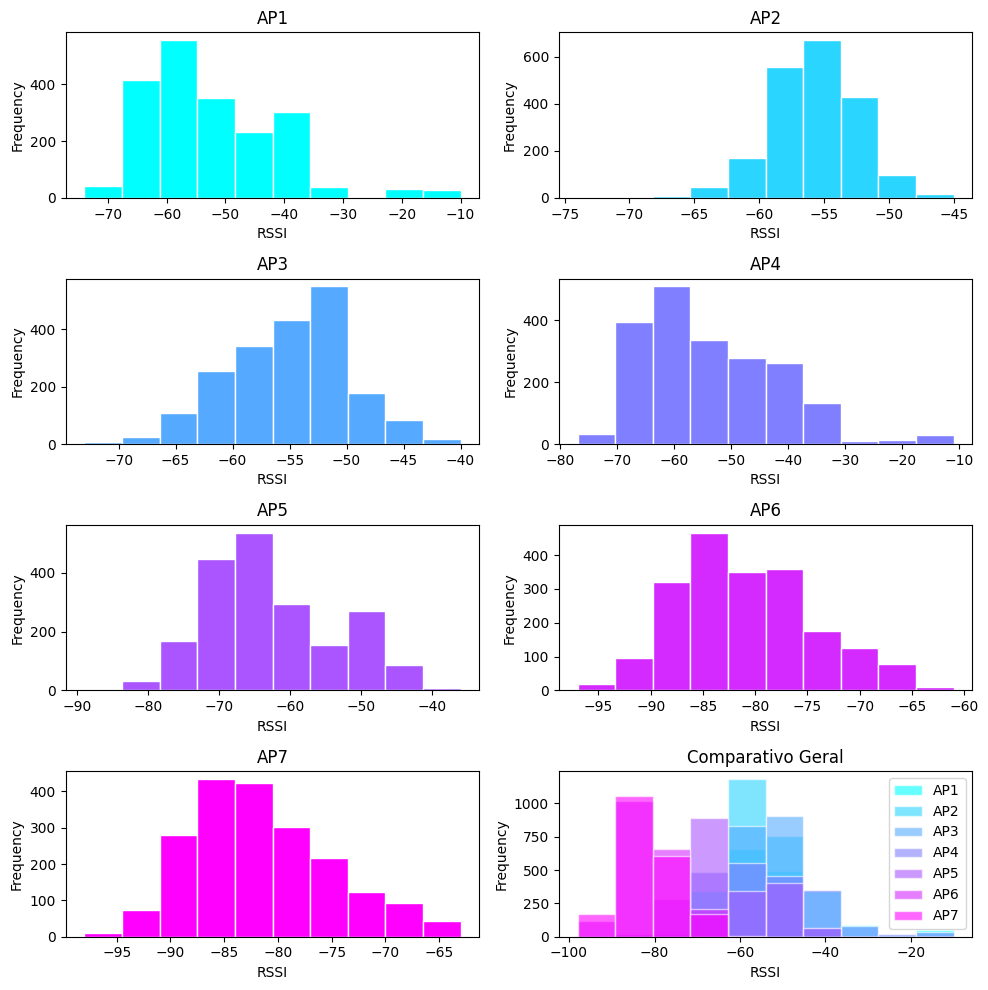

In [6]:
fig, ax = plt.subplots(4, 2, figsize=(10, 10))
cmap = plt.colormaps['cool']
cores = cmap(np.linspace(0, 1, 7))

aps = ['AP1', 'AP2', 'AP3', 'AP4', 'AP5', 'AP6', 'AP7']
ax_flat = ax.flatten()

for i, name in enumerate(aps):
    df[name].plot.hist(ax=ax_flat[i], color=cores[i], edgecolor='white')
    ax_flat[i].set_title(name)
    ax_flat[i].set_xlabel('RSSI')

df[aps].plot.hist(ax=ax_flat[7], colormap='cool', alpha=0.6, edgecolor='white')
ax_flat[7].set_title('Comparativo Geral')
ax_flat[7].set_xlabel('RSSI')

fig.tight_layout()
plt.show()

Os Pontos de Acesso mais concentrados são o 2 e 3, enquanto os menos concentrados são o 4, 5 e 6. Essas diferenças podem ser importantes em tarefas de classificação e clusterização, pois quanto mais concentradas estão as amostras, mais precisão terá um classificador no final do treinamento, já que a probabilidade da amostra pertencer a outra classe diminui. No caso de clusterização, regiões mais coesas são formadas em casos de amostras mais concentradas.

### <font color='#2D9CDB'>Q5) Analise a distribuição das amostras entre as diferentes salas do dataset. Para isso, apresente a quantidade de exemplos pertencentes a cada classe e construa um gráfico de barras mostrando essa distribuição. Em seguida, informe se o conjunto de dados é balanceado e discuta brevemente como o balanceamento das classes pode influenciar o treinamento e a avaliação de modelos de classificação.</font>

Room
1    500
2    500
3    500
4    500
Name: count, dtype: int64


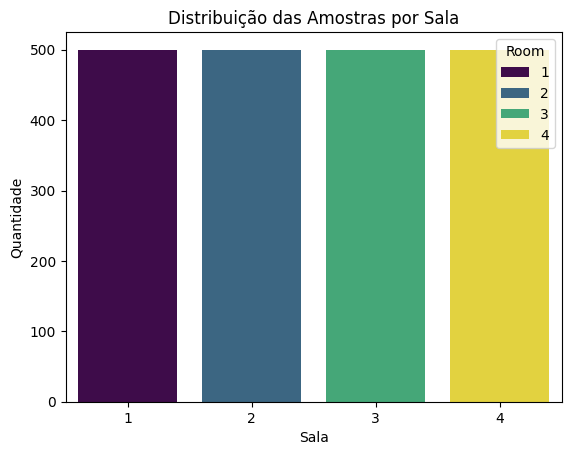

In [17]:
print(df['Room'].value_counts())

sns.countplot(x='Room', data=df, palette='viridis', hue='Room')
plt.xlabel('Sala')
plt.ylabel('Quantidade')
plt.title('Distribuição das Amostras por Sala')
plt.show()

A variável alvo é totalmente balanceada, pois todas as salas apresentam igual número de amostras (500). O balanceamento garante duas características: fronteiras de decisão centralizadas e foco nas features (não hávera interferência de qual sala aparece mais no histórico).

### <font color='#2D9CDB'>Q6) Divida o dataset em conjuntos de treinamento e teste utilizando 70% das amostras para treinamento e 30% para teste. Utilize estratificação para preservar a proporção das classes em ambos os conjuntos. Em seguida, informe a quantidade de amostras presente em cada conjunto e verifique se a distribuição das classes foi mantida após a divisão.</font>

In [19]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print(f'Quantidade de amostras no conjunto de treinamento: {len(x_train)}')
print(f'Quantidade de amostras no conjunto de teste: {len(x_test)}')

Quantidade de amostras no conjunto de treinamento: 1400
Quantidade de amostras no conjunto de teste: 600


Como as classes 'Room' são balanceadas entre si, houve manutenção das distribuições após a divisão.

# <font color='green'><u><b>Parte 2 - Árvore de Decisão</b></u></font>

### <font color='#2D9CDB'>Q7) Treine uma árvore de decisão para classificar as salas do dataset utilizando os dados de treinamento. Em seguida, informe a profundidade da árvore, o número de nós folha e apresente uma visualização da estrutura aprendida pelo modelo. Com base na árvore obtida, identifique qual atributo foi utilizado no nó raiz e discuta brevemente o que isso indica sobre sua importância para o processo de classificação.</font>

In [28]:
import graphviz
from sklearn import tree

Profundidade da árvore: 12
Número de nós folha: 31


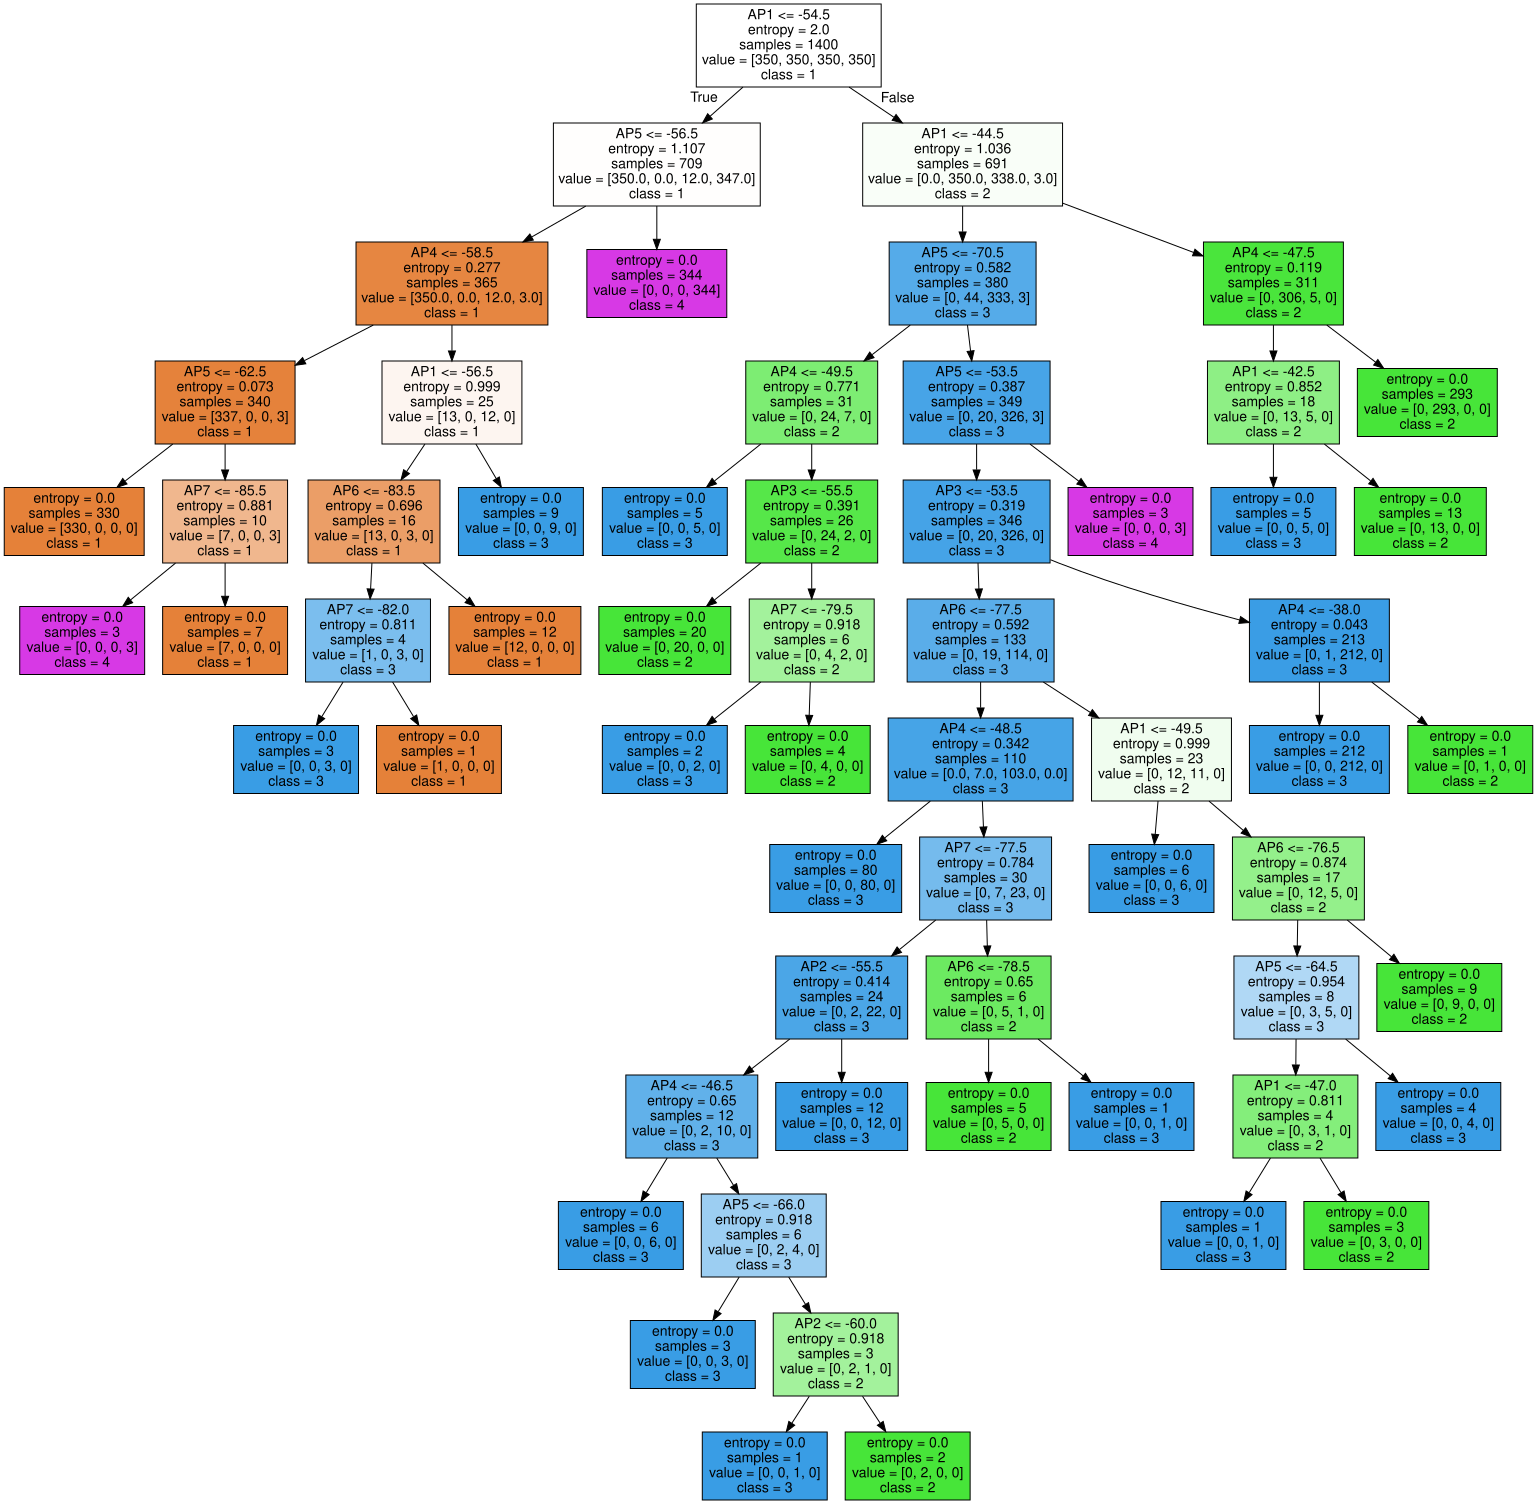

In [33]:
clf = DecisionTreeClassifier(criterion='entropy', random_state=seed)

clf.fit(x_train, y_train)

print(f'Profundidade da árvore: {clf.get_depth()}')
print(f'Número de nós folha: {clf.get_n_leaves()}')

class_names_str = [str(name) for name in df['Room'].unique()]

tree_data = tree.export_graphviz(clf, out_file=None, feature_names=feature_names, class_names=class_names_str, filled=True) # Assim como em sala
graph = graphviz.Source(tree_data, format='png')
graph



O nó raiz foi o atributo AP1. Isso indica que este atributo é o mais informativo de todo o dataset para separação das salas.

### <font color='#2D9CDB'>Q8) Utilize a árvore de decisão treinada para realizar predições sobre o conjunto de teste. Em seguida, calcule a acurácia do modelo e apresente a matriz de confusão correspondente. Com base nos resultados obtidos, analise o desempenho do classificador e identifique quais salas foram classificadas com maior e menor precisão.</font>

Acurácia do modelo no treino: 1.0
Acurácia do modelo no teste: 0.9666666666666667


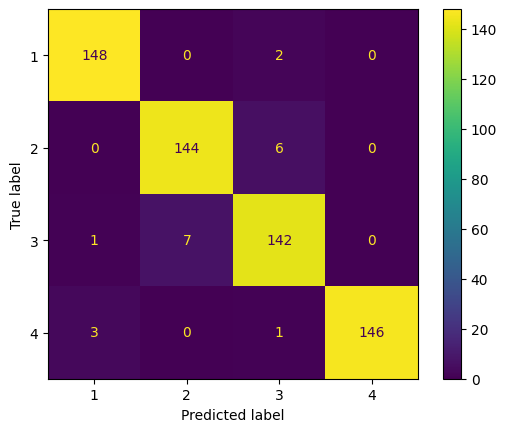

In [36]:
y_pred_train = clf.predict(x_train)
print(f'Acurácia do modelo no treino: {accuracy_score(y_train, y_pred_train)}')
y_pred_test = clf.predict(x_test)
print(f'Acurácia do modelo no teste: {accuracy_score(y_test, y_pred_test)}')

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='viridis')
plt.show()

As salas 1 e 4 foram classificadas com maior exatidão, enquanto as classes 2 e 3 com menor precisão.

Analisando os valores altos da acurácia, nota-se que o classificador conseguiu separar bem as classes analisadas.

### <font color='#2D9CDB'>Q9) Treine novas árvores de decisão limitando a profundidade máxima (`max_depth`) aos valores de 1 a 15. Para cada modelo, calcule a acurácia nos conjuntos de treinamento e teste. Em seguida, organize os resultados em uma tabela e construa um gráfico comparando as acurácias obtidas. Com base nos resultados, analise como a profundidade influencia a complexidade e o desempenho do modelo. Por fim, identifique se há evidências de sobreajuste e indique qual profundidade parece oferecer o melhor equilíbrio entre capacidade de aprendizado e generalização.</font>

In [37]:
clf1 = DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=seed)
clf1.fit(x_train, y_train)

clf5 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=seed)
clf5.fit(x_train, y_train)

clf10 = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=seed)
clf10.fit(x_train, y_train)

clf15 = DecisionTreeClassifier(criterion='entropy', max_depth=15, random_state=seed)
clf15.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=15, random_state=42)

In [38]:
y_pred_train1 = clf1.predict(x_train)
print(f'Acurácia do modelo no treino: {accuracy_score(y_train, y_pred_train1)}')
y_pred_test1 = clf1.predict(x_test)
print(f'Acurácia do modelo no teste: {accuracy_score(y_test, y_pred_test1)}')

y_pred_train5 = clf5.predict(x_train)
print(f'Acurácia do modelo no treino: {accuracy_score(y_train, y_pred_train5)}')
y_pred_test5 = clf5.predict(x_test)
print(f'Acurácia do modelo no teste: {accuracy_score(y_test, y_pred_test5)}')

y_pred_train10 = clf10.predict(x_train)
print(f'Acurácia do modelo no treino: {accuracy_score(y_train, y_pred_train10)}')
y_pred_test10 = clf10.predict(x_test)
print(f'Acurácia do modelo no teste: {accuracy_score(y_test, y_pred_test10)}')

y_pred_train15 = clf15.predict(x_train)
print(f'Acurácia do modelo no treino: {accuracy_score(y_train, y_pred_train15)}')
y_pred_test15 = clf15.predict(x_test)
print(f'Acurácia do modelo no teste: {accuracy_score(y_test, y_pred_test15)}')

Acurácia do modelo no treino: 0.5
Acurácia do modelo no teste: 0.5
Acurácia do modelo no treino: 0.9835714285714285
Acurácia do modelo no teste: 0.9683333333333334
Acurácia do modelo no treino: 0.9985714285714286
Acurácia do modelo no teste: 0.97
Acurácia do modelo no treino: 1.0
Acurácia do modelo no teste: 0.9666666666666667


In [47]:
table = pd.DataFrame(columns=['Profundidade', 'Acurácia Treino', 'Acurácia Teste'])
table['Profundidade'] = [1, 5, 10, 15]
table['Acurácia Treino'] = [accuracy_score(y_train, y_pred_train1), accuracy_score(y_train, y_pred_train5), accuracy_score(y_train, y_pred_train10), accuracy_score(y_train, y_pred_train15)]
table['Acurácia Teste'] = [accuracy_score(y_test, y_pred_test1), accuracy_score(y_test, y_pred_test5), accuracy_score(y_test, y_pred_test10), accuracy_score(y_test, y_pred_test15)]
display(table)

,Profundidade,Acurácia Treino,Acurácia Teste
0,1,0.500000,0.500000
1,5,0.983571,0.968333
2,10,0.998571,0.970000
3,15,1.000000,0.966667


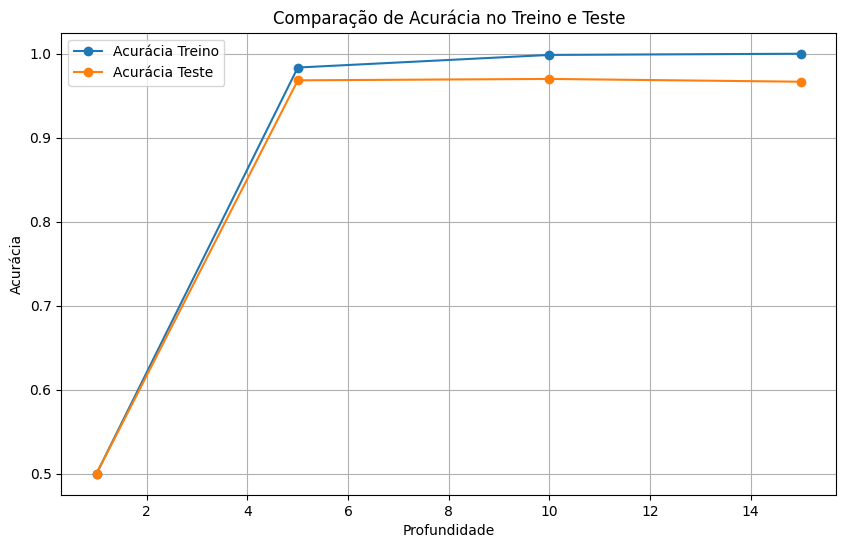

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(table['Profundidade'], table['Acurácia Treino'], marker='o', label='Acurácia Treino')
plt.plot(table['Profundidade'], table['Acurácia Teste'], marker='o', label='Acurácia Teste')
plt.xlabel('Profundidade')
plt.ylabel('Acurácia')
plt.title('Comparação de Acurácia no Treino e Teste')
plt.legend()
plt.grid(True)

A relação observada é que quanto maior o valor da profundidade, maior a acurácia em ambos (treino e teste), portanto maior desempenho final. Mas um valor muito grande de profundidade pode causar overfitting. Podemos notar que tanto 10 quanto 15 apresentam acurácias muito semelhantes, mas o caso de 15 pode haver overfitting por apresentar uma complexidade muito maior. Logo, nesta análise, o melhor valor para profundidade balanceando desempenho e complexidade foi usando 10.

### <font color='#2D9CDB'>Q10) Utilizando a árvore de decisão treinada, obtenha a importância de cada atributo RSSI por meio da propriedade `feature_importances_`. Em seguida, construa um gráfico de barras ordenando os atributos do mais importante para o menos importante. Com base nos resultados, identifique quais pontos de acesso contribuíram mais para a classificação das salas e discuta por que alguns atributos podem ser mais relevantes do que outros para o problema de localização indoor.</font>

Importância dos atributos: {'AP1': np.float64(0.6420929609816699), 'AP2': np.float64(0.002333769076998739), 'AP3': np.float64(0.009681011477915946), 'AP4': np.float64(0.04015080303399574), 'AP5': np.float64(0.2826956376137143), 'AP6': np.float64(0.013294713396695954), 'AP7': np.float64(0.009751104419009476)}


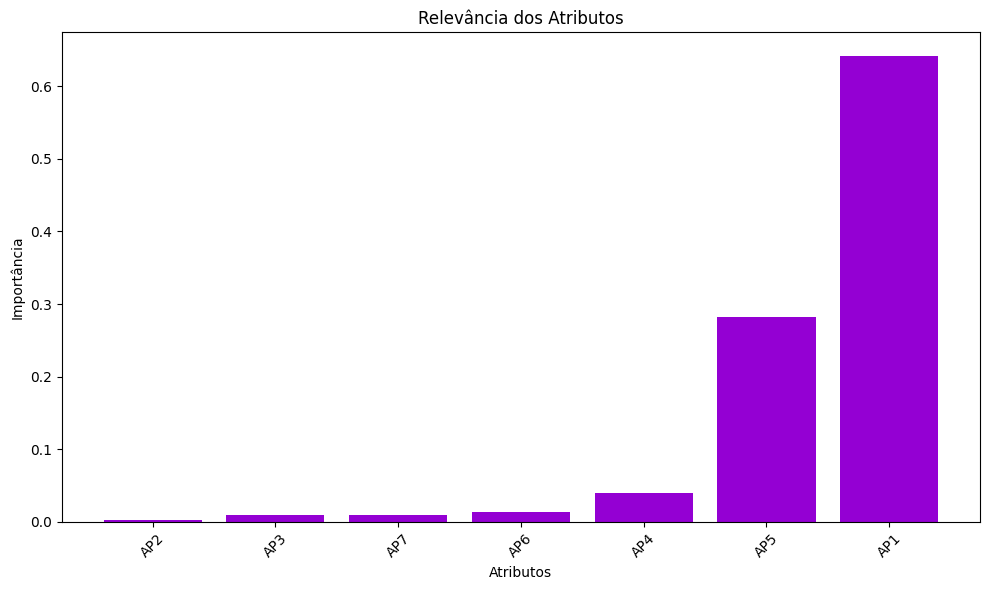

In [74]:
print(f'Importância dos atributos: {dict(zip(feature_names, clf10.feature_importances_))}')

importances = clf10.feature_importances_
indices_ordenados = np.argsort(importances)
feature_names_ordenados = [feature_names[i] for i in indices_ordenados]
importances_ordenadas = importances[indices_ordenados]

plt.figure(figsize=(10, 6))
plt.bar(feature_names_ordenados, importances_ordenadas, color='darkviolet')

plt.xlabel('Atributos')
plt.ylabel('Importância')
plt.title('Relevância dos Atributos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Os atributos mais relevantes foram `AP1` e `AP5`. Alguns atributos podem ser mais relevantes do que outros porque a localização indoor depende de fatores como disposição física, barreiras físicas e estabilidade que podem influenciar positivamente ou negativamente em cada um.

# <font color='green'><u><b>Parte 3 - K-Means</b></u></font>

### <font color='#2D9CDB'>Q11) Diferentemente das árvores de decisão, o algoritmo k-Means não utiliza rótulos durante o treinamento. Pesquise brevemente sobre esse método e descreva, em um único parágrafo, o que é clusterização, qual é o objetivo do algoritmo k-Means, o significado de um centroide e como o algoritmo utiliza a distância entre as amostras para formar agrupamentos.</font>

A clusterização é uma técnica de aprendizado não supervisionado que agrupa dados sem rótulos com base em suas semelhanças, onde o objetivo do algoritmo k-Means é dividir o conjunto de dados em um número pré-definido (k) de grupos (clusters) distintos e homogêneos. Para isso, ele utiliza centroides, que funcionam como os pontos médios geométricos de cada grupo no espaço. O algoritmo funciona calculando iterativamente a distância entre cada amostra e os centroides disponíveis, associando cada dado ao centroide mais próximo e, em seguida, recalculando a posição desses centros até que os agrupamentos se estabilizem com as amostras mais concentradas ao redor de seus respectivos eixos.

### <font color='#2D9CDB'>Q12) Considere os dois atributos mais importantes identificados na Q10. Construa um gráfico de dispersão utilizando essas variáveis, representando as amostras de cada sala com cores distintas e uma legenda apropriada. Com base na visualização obtida, analise a distribuição das amostras e discuta se existem agrupamentos naturais nos dados. Na sua opinião, seria possível identificar as diferentes salas sem utilizar os rótulos originais?</font>

Text(0, 0.5, 'AP5')

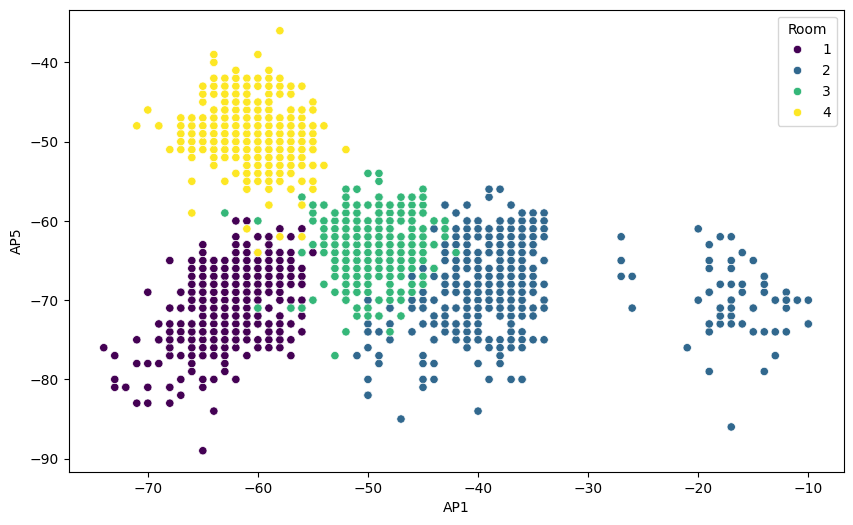

In [75]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='AP1', y='AP5', hue='Room', palette='viridis')
plt.xlabel('AP1')
plt.ylabel('AP5')

Com a divisão e separação por cores, é possível observar que existem agrupamentos naturais entre os dados. Seria possível sim identificar sem rótulos, isso poderia ser feito por meio da clusterização.

### <font color='#2D9CDB'>Q13) Antes de aplicar o algoritmo k-Means, é necessário definir o número de clusters (*k*). Utilize o Método do Cotovelo (Elbow Method) para avaliar valores de *k* entre 1 e 10. Para cada valor, calcule a inércia do modelo e construa um gráfico relacionando o número de clusters e a inércia obtida. Com base no gráfico, identifique o valor de *k* que parece mais adequado para este conjunto de dados e justifique sua escolha.</font>

In [78]:
inercia = []
numMaxClusters = 10
for k in range(1, numMaxClusters+1):
    kmeans = KMeans(n_clusters=k, random_state=seed)
    kmeans.fit(df[['AP1', 'AP5']])
    inercia.append(kmeans.inertia_)

Número ideal de clusters calculado: k = 4


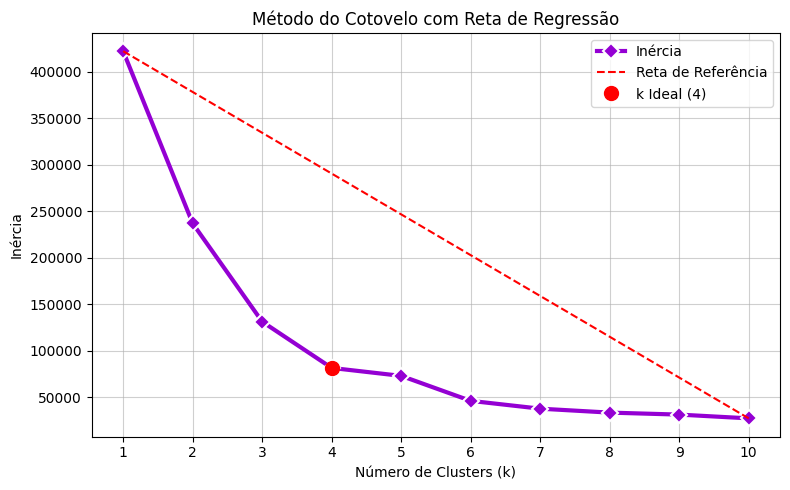

In [92]:
x_reta = np.array([1, numMaxClusters])
y_reta_extremos = np.array([inercia[0], inercia[-1]])
a, b = np.polyfit(x_reta, y_reta_extremos, 1)

distancias = []
for k in range(1, numMaxClusters + 1):
    y_na_reta = a * k + b
    distancia = abs(inercia[k - 1] - y_na_reta)
    distancias.append(distancia)

k_otimo = np.argmax(distancias) + 1
print(f"Número ideal de clusters calculado: k = {k_otimo}")

plt.figure(figsize=(8, 5))

plt.plot(k_values, inercia, marker='D', linestyle='-', color='darkviolet',
         linewidth=3, markersize=8, markeredgecolor='white', markeredgewidth=1.5, label='Inércia')
plt.plot(x_reta, a * x_reta + b, 'r--', label='Reta de Referência')
plt.plot(k_otimo, inercia[k_otimo - 1], 'ro', markersize=10, label=f'k Ideal ({k_otimo})')

plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo com Reta de Regressão')
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.6)

plt.tight_layout()
plt.show()

O valor mais adequado foi k = 4, usando distância euclidiana para uma reta de referência.

### <font color='#2D9CDB'>Q14) Utilizando o valor de *k* identificado na Q13, treine um modelo k-Means empregando apenas os atributos AP1 e AP5. Em seguida, apresente as coordenadas dos centroides encontrados e construa um gráfico de dispersão mostrando as amostras coloridas de acordo com o cluster atribuído pelo algoritmo. Destaque também os centroides no gráfico. Com base nos resultados, analise a qualidade dos agrupamentos obtidos.</font>

Coordenadas dos centroides: [[-34.83709273 -67.81203008]
 [-60.20724346 -49.3722334 ]
 [-62.37747036 -70.42490119]
 [-48.9548495  -63.63043478]]


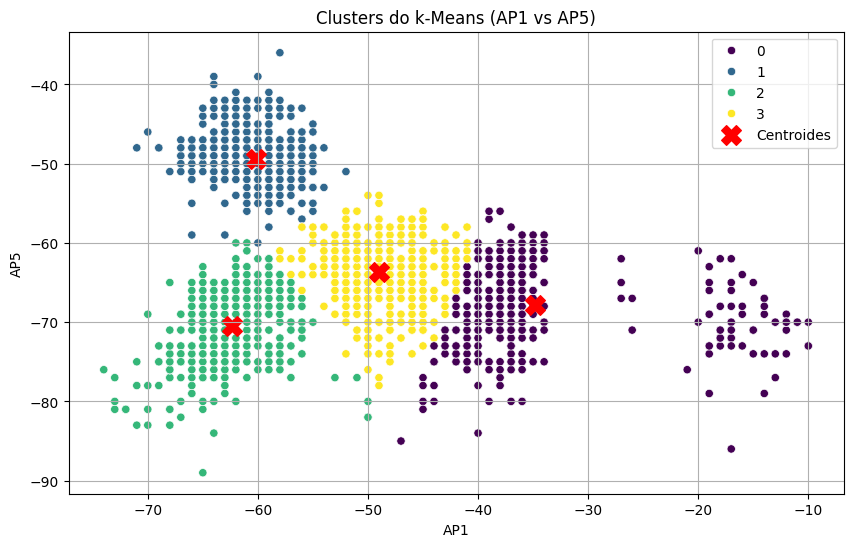

In [96]:
kmeans = KMeans(n_clusters=4, random_state=seed)
kmeans.fit(df[['AP1', 'AP5']])

print(f'Coordenadas dos centroides: {kmeans.cluster_centers_}')

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['AP1'], y=df['AP5'], hue=kmeans.labels_, palette='viridis', legend='full')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroides')
plt.xlabel('AP1')
plt.ylabel('AP5')
plt.title('Clusters do k-Means (AP1 vs AP5)')
plt.legend()
plt.grid(True)
plt.show()

Os agrupamentos estão bem demarcados no gráfico de dispersão.

### <font color='#2D9CDB'>Q15) Compare os clusters encontrados pelo k-Means com as salas reais do dataset. Para isso, construa uma <a href="https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html">tabela de contingência</a> relacionando cada sala aos clusters atribuídos pelo algoritmo. Em seguida, identifique qual cluster representa predominantemente cada sala e calcule a porcentagem de amostras associadas a esse agrupamento. Com base nos resultados, discuta quais salas foram mais facilmente identificadas pelo algoritmo e quais apresentaram maior grau de confusão com outros grupos.</font>

In [97]:
contingency_table = pd.crosstab(df['Room'], kmeans.labels_)
display(contingency_table)

col_0,0,1,2,3
Room,,,,
1,0,0,493,7
2,397,0,4,99
3,0,3,7,490
4,0,494,2,4


In [98]:
# Qual cluster para cada sala:
room1 = contingency_table.iloc[0].idxmax()
room2 = contingency_table.iloc[1].idxmax()
room3 = contingency_table.iloc[2].idxmax()
room4 = contingency_table.iloc[3].idxmax()
pctR1 = contingency_table.iloc[0].max() / contingency_table.iloc[0].sum()
pctR2 = contingency_table.iloc[1].max() / contingency_table.iloc[1].sum()
pctR3 = contingency_table.iloc[2].max() / contingency_table.iloc[2].sum()
pctR4 = contingency_table.iloc[3].max() / contingency_table.iloc[3].sum()

print(f'Sala 1: {room1}, {pctR1:.2%}')
print(f'Sala 2: {room2}, {pctR2:.2%}')
print(f'Sala 3: {room3}, {pctR3:.2%}')
print(f'Sala 4: {room4}, {pctR4:.2%}')

Sala 1: 2, 98.60%
Sala 2: 0, 79.40%
Sala 3: 3, 98.00%
Sala 4: 1, 98.80%


3 salas apresentaram valores semelhantes e altos na identificação: 1, 3 e 4. Somente a sala 2 apresentou maior grau de confusão com outras salas.

# <font color='green'><u><b>Parte 4 - Detecção de Anomalias</b></u></font>

### <font color='#2D9CDB'>Q16) Uma aplicação comum de algoritmos de clusterização é a detecção de anomalias. Em geral, amostras localizadas muito longe do centroide de seu cluster podem representar comportamentos incomuns ou situações atípicas. Utilizando os dois atributos mais importantes identificados na Q10, calcule a distância euclidiana de cada amostra ao centroide do cluster ao qual ela foi atribuída pelo k-Means. Em seguida, apresente um histograma dessas distâncias e informe os valores mínimo, máximo, médio e o desvio padrão observados. Com base nos resultados, discuta o que essas distâncias revelam sobre a compactação dos clusters encontrados.</font>

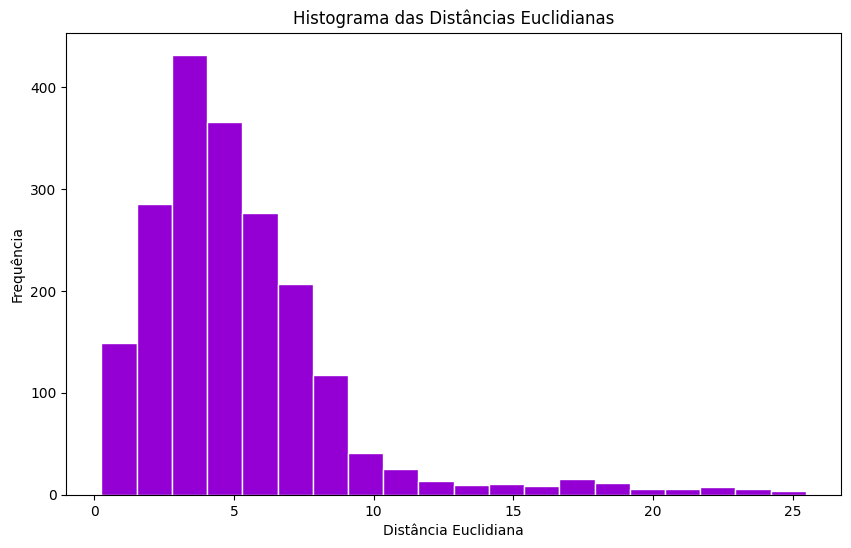

Mínimo: 0.24873976492831062
Máximo: 25.474774328926895
Média: 5.232556584810507
Desvio Padrão:"3.6709843221123517


In [105]:
distancias = []
for i in range(len(df)):
    distancias.append(np.linalg.norm(df.iloc[i][['AP1', 'AP5']] - kmeans.cluster_centers_[kmeans.labels_[i]]))

df['Distância'] = distancias

plt.figure(figsize=(10, 6))
plt.hist(distancias, bins=20, color='darkviolet', edgecolor='white')
plt.xlabel('Distância Euclidiana')
plt.ylabel('Frequência')

plt.title('Histograma das Distâncias Euclidianas')
plt.show()

print(f'Mínimo: {np.min(distancias)}')
print(f'Máximo: {np.max(distancias)}')
print(f'Média: {np.mean(distancias)}')
print(f'Desvio Padrão:"{np.std(distancias)}')


O histograma mostra que a maior concentração ocorre para um distância relativamente pequena e diminui para distâncias maiores, o que pode ser observado já que, em geral, os pontos estão compactos.

### <font color='#2D9CDB'>Q17) Considere que amostras muito distantes do centroide de seu cluster podem ser classificadas como potenciais anomalias. Utilize o percentil de 95% das distâncias calculadas na Q16 como limiar de detecção. Em seguida, identifique todas as amostras cuja distância ao centroide seja superior a esse valor, informe quantas anomalias foram encontradas e apresente as cinco amostras mais distantes de seus respectivos centroides. Com base nos resultados, discuta se o critério adotado parece adequado para identificar observações atípicas.</font>

In [110]:
anomalia = np.percentile(distancias, 95)
print(f'Limiar de Anomalia: {anomalia}')

anomalias = df[df['Distância'] > anomalia]
print(f'Anomalias encontradas: {len(anomalias)}')
display(anomalias.sort_values(by='Distância', ascending=False).head(5))

Limiar de Anomalia: 11.588762628289642
Anomalias encontradas: 100


,AP1,AP2,AP3,AP4,AP5,AP6,AP7,Room,Distância
609,-17,-63,-65,-27,-86,-72,-74,2,25.474774
769,-10,-57,-57,-36,-73,-82,-72,2,25.373139
873,-10,-58,-62,-20,-73,-76,-74,2,25.373139
870,-10,-58,-54,-18,-70,-72,-73,2,24.933279
932,-11,-59,-60,-27,-70,-74,-71,2,23.937297


Sim, parece adequado, uma vez que esses valores estão muito distantes dos centroides dos clusters.

### <font color='#2D9CDB'>Q18) Construa um gráfico de dispersão utilizando os dois atributos empregados pelo k-Means e destaque as anomalias identificadas na Q17. Represente também os centroides dos clusters. Com base na visualização obtida, avalie se as amostras classificadas como anômalas encontram-se em regiões afastadas dos centroides e discuta se os resultados são coerentes com o critério de detecção adotado.</font>

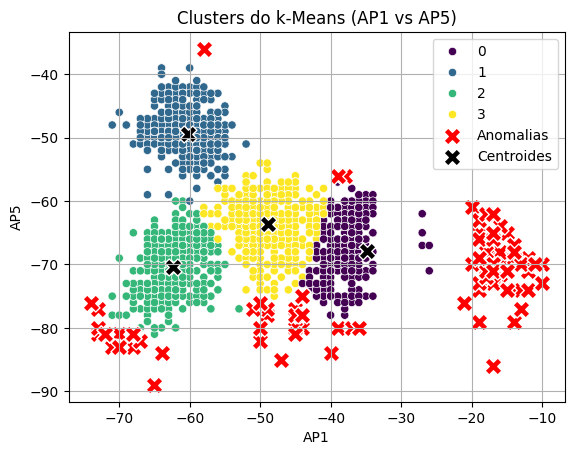

In [111]:
sns.scatterplot(x=df['AP1'], y=df['AP5'], hue=kmeans.labels_, palette='viridis', legend='full')
sns.scatterplot(x=anomalias['AP1'], y=anomalias['AP5'], color='red', marker='X', s=150, label='Anomalias')
sns.scatterplot(x=kmeans.cluster_centers_[:, 0], y=kmeans.cluster_centers_[:, 1], color='black', marker='X', s=150, label='Centroides')
plt.xlabel('AP1')
plt.ylabel('AP5')
plt.title('Clusters do k-Means (AP1 vs AP5)')
plt.legend()
plt.grid(True)
plt.show()

Sim, todas as anomalias se encontram em áreas distantes de seus centróides, sendo o método um sucesso com o critério utilizado.

### <font color='#2D9CDB'>Q19) O limiar utilizado para detectar anomalias influencia diretamente a quantidade de observações classificadas como atípicas. Repita o procedimento da Q17 utilizando os percentis 90%, 95% e 99% das distâncias aos centroides. Para cada caso, registre o valor do limiar e o número de anomalias detectadas. Organize os resultados em uma tabela e discuta como a escolha do percentil afeta a sensibilidade do detector de anomalias.</font>

In [117]:
anomalia90 = np.percentile(distancias, 90)
print(f'Limiar de Anomalia para 90%: {anomalia90}')

anomalias = df[df['Distância'] > anomalia90]
print(f'Anomalias encontradas: {len(anomalias)}')

print()

anomalia = np.percentile(distancias, 95)
print(f'Limiar de Anomalia para 95%: {anomalia}')

anomalias = df[df['Distância'] > anomalia]
print(f'Anomalias encontradas: {len(anomalias)}')

print()

anomalia99 = np.percentile(distancias, 99)
print(f'Limiar de Anomalia para 99%: {anomalia99}')

anomalias = df[df['Distância'] > anomalia99]
print(f'Anomalias encontradas: {len(anomalias)}')

table_anomalias = pd.DataFrame(columns=['Limiar', 'Anomalias'])
table_anomalias['Limiar'] = [anomalia90, anomalia, anomalia99]
table_anomalias['Anomalias'] = [len(df[df['Distância'] > anomalia90]), len(df[df['Distância'] > anomalia]), len(df[df['Distância'] > anomalia99])]
display(table_anomalias)

Limiar de Anomalia para 90%: 8.565266119807958
Anomalias encontradas: 200

Limiar de Anomalia para 95%: 11.588762628289642
Anomalias encontradas: 100

Limiar de Anomalia para 99%: 20.8530895058741
Anomalias encontradas: 20


,Limiar,Anomalias
0,8.565266,200
1,11.588763,100
2,20.853090,20


Analisando a tabela, podemos inferir que quanto maior o limiar (porcentagem), menor a quantidade de anomalias. Sendo 99% o caso em que menos anomalias foram encontradas.

# <font color='green'><u><b>Parte 5 - Análise Final</b></u></font>

### <font color='#2D9CDB'>Q20) Ao longo desta atividade foram exploradas técnicas de aprendizado supervisionado (Árvores de Decisão) e não supervisionado (k-Means), além de uma abordagem simples para detecção de anomalias baseada na distância aos centroides. Compare essas três aplicações quanto aos seus objetivos, à utilização de rótulos durante o treinamento, aos resultados produzidos e às situações em que cada uma delas é mais adequada. Por fim, discuta como essas técnicas poderiam ser utilizadas em conjunto em um sistema de localização indoor baseado em sinais Wi-Fi.</font>

As três técnicas se complementam ao atacar diferentes etapas do problema: enquanto a Árvore de Decisão utiliza dados rotulados para criar regras lógicas de alta precisão que classificam a sala exata do usuário em tempo real, o k-Means opera de forma não supervisionada para agrupar assinaturas de sinal semelhantes e descobrir divisões espaciais de forma automática quando não há rótulos prévios, e a Detecção de Anomalias calcula a distância aos centroides para isolar leituras absurdas causadas por interferências ou roteadores desligados. Em um sistema de localização indoor integrado, o k-Means mapeia inicialmente o ambiente criando os grupos de sinais, a detecção de anomalias atua como um filtro de segurança limpando ruídos e dados corrompidos na entrada, e a Árvore de Decisão consome essa base de dados refinada para executar uma navegação instantânea, leve e altamente confiável para o usuário final.